<a href="https://colab.research.google.com/github/UO295831/Computer-Vision-project-2/blob/main/CV_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
import torch

# This checks if Colab gave you a GPU. If yes, it uses 'cuda'. If no, it falls back to 'cpu'.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch is currently using: {DEVICE}")

# Let's double check exactly which graphics card you were assigned
if torch.cuda.is_available():
    print(f"Graphics Card: {torch.cuda.get_device_name(0)}")

PyTorch is currently using: cpu


# Globals

In [5]:
# --- Hardware ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch is currently using: {DEVICE}")
if torch.cuda.is_available():
    print(f"Graphics Card: {torch.cuda.get_device_name(0)}")

# --- Hyperparameters ---
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 20

# --- Paths ---
base_path = "/content/drive/MyDrive/CV_project/CV_Project_data/"
DATA_DIR = "/content/drive/MyDrive/CV_project/CV_Project_data/RRDataset_Subset"
DATA_DIR1 = "/content/drive/MyDrive/CV_project/CV_Project_data/RRDataset_Mini_Subset"


PyTorch is currently using: cpu


#Utils

In [ ]:
def plot_training_history(train_losses, val_losses, title="Training History"):
    """Plots the loss curves for your final report."""
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', color='red', linewidth=2)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

# Data

###  One-Time Setup (Run Once & Collapse) NO RUN

In [ ]:
# Downloading the file directly into the Drive folder, since is to heavy for our personal laptops
!wget https://zenodo.org/records/14963880/files/RRDataset_test.tar.gz?download=1 -P /content/drive/MyDrive/CV_project/CV_Project_data/

In [ ]:
# 1. DELETE THE ARCHIVE TO FREE UP SPACE
archive_path = "/content/drive/MyDrive/CV_project/CV_Project_data/RRDataset_test.tar.gz"
if os.path.exists(archive_path):
    os.remove(archive_path)
    print("Deleted the 20GB .tar.gz file to free up your Google Drive space!")

# 2. PEEK INSIDE THE NEW FOLDER
dataset_path = "/content/drive/MyDrive/CV_project/CV_Project_data/RRDataset_final"

print("\n Inside 'RRDataset_final':")
for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)
    if os.path.isdir(item_path):
        print(f"\n📁 [MAIN FOLDER] {item}")
        # Look one level deeper to see the subfolders
        subfolders = [f for f in os.listdir(item_path) if os.path.isdir(os.path.join(item_path, f))]
        if subfolders:
            print(f"   ↳ Subfolders: {subfolders}")

In [ ]:

base_path = "/content/drive/MyDrive/CV_project/CV_Project_data/"

print("Inspecting dataset\n")

# Go through the main data folder
for main_item in sorted(os.listdir(base_path)):
    main_path = os.path.join(base_path, main_item)
    if os.path.isdir(main_path):
        print(f"📁 {main_item}/")

        # Look inside each folder (e.g., RRDataset_final)
        for sub_item in sorted(os.listdir(main_path)):
            sub_path = os.path.join(main_path, sub_item)
            if os.path.isdir(sub_path):
                print(f"   ┣━ 📁 {sub_item}/")

                # Peek one more level deep to see the "ai" / "real" splits
                for deep_item in sorted(os.listdir(sub_path)):
                    deep_path = os.path.join(sub_path, deep_item)
                    if os.path.isdir(deep_path):
                        print(f"   ┃  ┣━ 📁 {deep_item}/")

Inspecting dataset

📁 RRDataset_Mini_Subset/
   ┣━ 📁 Fake_AI/
   ┃  ┣━ 📁 Original/
   ┃  ┣━ 📁 Redigitized/
   ┃  ┣━ 📁 Transmitted/
   ┣━ 📁 Real/
   ┃  ┣━ 📁 Original/
   ┃  ┣━ 📁 Redigitized/
   ┃  ┣━ 📁 Transmitted/
📁 RRDataset_Subset/
   ┣━ 📁 Fake_AI/
   ┃  ┣━ 📁 Original/
   ┃  ┣━ 📁 Redigitized/
   ┃  ┣━ 📁 Transmitted/
   ┣━ 📁 Real/
   ┃  ┣━ 📁 Original/
   ┃  ┣━ 📁 Redigitized/
   ┃  ┣━ 📁 Transmitted/
📁 RRDataset_final/
   ┣━ 📁 redigital/
   ┃  ┣━ 📁 ai/
   ┃  ┣━ 📁 real/
   ┣━ 📁 transfer/
   ┃  ┣━ 📁 ai/
   ┃  ┣━ 📁 real/
📁 RRDataset_original_train_val/
   ┣━ 📁 train/
   ┃  ┣━ 📁 ai/
   ┃  ┣━ 📁 real/
   ┣━ 📁 val/
   ┃  ┣━ 📁 ai/
   ┃  ┣━ 📁 real/


### **EDA** for the subsampling

,Authenticity,Transformation,Images
0,Real,Original,1250
1,Fake_AI,Original,1250
2,Real,Transmitted,4079
3,Fake_AI,Transmitted,8500
4,Real,Redigitized,8499
5,Fake_AI,Redigitized,8500



Total images: 32078


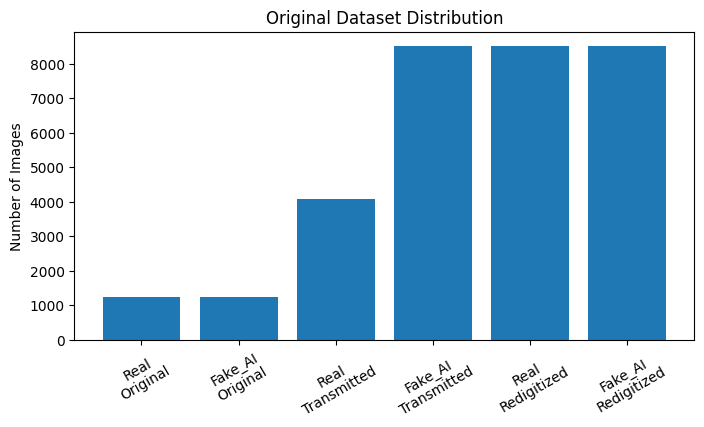

In [ ]:
base_path = "/content/drive/MyDrive/CV_project/CV_Project_data/"

source_mappings = {
    ("Real", "Original"): os.path.join(base_path, "RRDataset_original_train_val/train/real"),
    ("Fake_AI", "Original"): os.path.join(base_path, "RRDataset_original_train_val/train/ai"),
    ("Real", "Transmitted"): os.path.join(base_path, "RRDataset_final/transfer/real"),
    ("Fake_AI", "Transmitted"): os.path.join(base_path, "RRDataset_final/transfer/ai"),
    ("Real", "Redigitized"): os.path.join(base_path, "RRDataset_final/redigital/real"),
    ("Fake_AI", "Redigitized"): os.path.join(base_path, "RRDataset_final/redigital/ai")
}

rows = []

for (rf_class, tf_class), path in source_mappings.items():

    count = len([
        f for f in os.listdir(path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    rows.append({
        "Authenticity": rf_class,
        "Transformation": tf_class,
        "Images": count
    })

df_original = pd.DataFrame(rows)

display(df_original)

print("\nTotal images:", df_original["Images"].sum())

plt.figure(figsize=(8,4))

labels = (
    df_original["Authenticity"]
    + "\n"
    + df_original["Transformation"]
)

plt.bar(labels, df_original["Images"])

plt.title("Original Dataset Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)

plt.show()

Data Strategy: Addressing the Imbalance
As shown in the distribution graph above, there is a physical limitation in our source data: the Original dataset caps out at exactly 1,250 images per class, while the other transformations contain significantly more.

A core requirement of this project's rubric is to maintain perfect class balance across both Authenticity (Real vs. Fake) and Transformation type. If we train on the raw distribution, the ConvNeXt model will develop a bias toward predicting "Transmitted" simply because it has more training examples.

The Solution: We will mathematically balance the dataset by subsampling every category down to the lowest common denominator: 1,250 images. This guarantees an unbiased, perfectly balanced final dataset of 7,500 images

### Subsample

In [ ]:
random.seed(42)

target_base = os.path.join(base_path, "RRDataset_Balanced_Subset")
SAMPLES_PER_CLASS = 1250

print(f" Building the BALANCED subset ({SAMPLES_PER_CLASS} images per class)...\n")

# 2. Execute the Subsampling
for (rf_class, tf_class), source_dir in source_mappings.items():
    target_dir = os.path.join(target_base, rf_class, tf_class)
    os.makedirs(target_dir, exist_ok=True)

    if os.path.exists(source_dir):
        all_images = [f for f in os.listdir(source_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Sample EXACTLY 1,250 images
        selected_images = random.sample(all_images, min(SAMPLES_PER_CLASS, len(all_images)))

        copied_count = 0
        for img_name in selected_images:
            src_path = os.path.join(source_dir, img_name)
            dst_path = os.path.join(target_dir, img_name)

            # Copy only if it isn't already there
            if not os.path.exists(dst_path):
                shutil.copy2(src_path, dst_path)
                copied_count += 1

        print(f"✅ Verified {len(os.listdir(target_dir))} images ready in [{rf_class} / {tf_class}]")
    else:
        print(f" Missing source directory: {source_dir}")

print("\n Balanced Subset Generation Complete!")

 Building the BALANCED subset (1250 images per class)...

✅ Verified 1250 images ready in [Real / Original]
✅ Verified 1250 images ready in [Fake_AI / Original]
✅ Verified 1250 images ready in [Real / Transmitted]
✅ Verified 1250 images ready in [Fake_AI / Transmitted]


In [7]:
random.seed(42)

base_path = "/content/drive/MyDrive/CV_project/CV_Project_data/"
target_base = os.path.join(base_path, "RRDataset_Balanced_Subset")
SAMPLES_PER_CLASS = 1250

# Redefine the mappings just in case the runtime forgot them
source_mappings = {
    ("Real", "Original"): os.path.join(base_path, "RRDataset_original_train_val/train/real"),
    ("Fake_AI", "Original"): os.path.join(base_path, "RRDataset_original_train_val/train/ai"),
    ("Real", "Transmitted"): os.path.join(base_path, "RRDataset_final/transfer/real"),
    ("Fake_AI", "Transmitted"): os.path.join(base_path, "RRDataset_final/transfer/ai"),
    ("Real", "Redigitized"): os.path.join(base_path, "RRDataset_final/redigital/real"),
    ("Fake_AI", "Redigitized"): os.path.join(base_path, "RRDataset_final/redigital/ai")
}

print("🔍 Scanning folders to resume interrupted extraction...\n")

for (rf_class, tf_class), source_dir in source_mappings.items():
    target_dir = os.path.join(target_base, rf_class, tf_class)
    os.makedirs(target_dir, exist_ok=True)

    if os.path.exists(source_dir):
        # 1. Check what is already safely in the destination folder
        existing_images = set(f for f in os.listdir(target_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg')))
        current_count = len(existing_images)

        # 2. Skip if it's already perfect
        if current_count >= SAMPLES_PER_CLASS:
            print(f"SKIP: [{rf_class} / {tf_class}] already perfect at {current_count} images.")
            continue

        # 3. Calculate exactly how many are missing
        needed_count = SAMPLES_PER_CLASS - current_count
        print(f" RESUMING: [{rf_class} / {tf_class}] has {current_count}. Fetching {needed_count} more...")

        all_source_images = [f for f in os.listdir(source_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Filter out images we already copied so we don't pick duplicates
        available_images = [img for img in all_source_images if img not in existing_images]

        # Sample only what is needed
        selected_images = random.sample(available_images, min(needed_count, len(available_images)))

        copied_count = 0
        for img_name in selected_images:
            src_path = os.path.join(source_dir, img_name)
            dst_path = os.path.join(target_dir, img_name)

            shutil.copy2(src_path, dst_path)
            copied_count += 1

        final_count = len(os.listdir(target_dir))
        print(f"FIXED: [{rf_class} / {tf_class}] is now perfectly balanced at {final_count} images.")
    else:
        print(f"Missing source directory: {source_dir}")

print("\nRescue Complete! You can now re-run your verification graph block.")

🔍 Scanning folders to resume interrupted extraction...

⏭️ SKIP: [Real / Original] already perfect at 1250 images.
⏭️ SKIP: [Fake_AI / Original] already perfect at 1250 images.
⏭️ SKIP: [Real / Transmitted] already perfect at 1250 images.
⏭️ SKIP: [Fake_AI / Transmitted] already perfect at 1250 images.
⏳ RESUMING: [Real / Redigitized] has 86. Fetching 1164 more...
✅ FIXED: [Real / Redigitized] is now perfectly balanced at 1250 images.
⏳ RESUMING: [Fake_AI / Redigitized] has 0. Fetching 1250 more...
✅ FIXED: [Fake_AI / Redigitized] is now perfectly balanced at 1250 images.

🎉 Rescue Complete! You can now re-run your verification graph block.


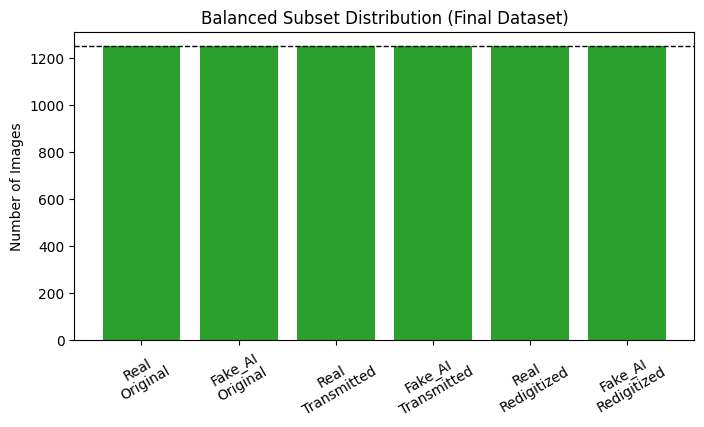


 Total mathematically balanced images ready for training: 7500


In [8]:
# Define paths for the newly created subset
target_base = os.path.join(base_path, "RRDataset_Balanced_Subset")
subset_mappings = {
    ("Real", "Original"): os.path.join(target_base, "Real", "Original"),
    ("Fake_AI", "Original"): os.path.join(target_base, "Fake_AI", "Original"),
    ("Real", "Transmitted"): os.path.join(target_base, "Real", "Transmitted"),
    ("Fake_AI", "Transmitted"): os.path.join(target_base, "Fake_AI", "Transmitted"),
    ("Real", "Redigitized"): os.path.join(target_base, "Real", "Redigitized"),
    ("Fake_AI", "Redigitized"): os.path.join(target_base, "Fake_AI", "Redigitized")
}

rows_subset = []

for (rf_class, tf_class), path in subset_mappings.items():
    count = len([f for f in os.listdir(path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    rows_subset.append({
        "Authenticity": rf_class,
        "Transformation": tf_class,
        "Images": count
    })

df_subset = pd.DataFrame(rows_subset)

# Plot the balanced data
plt.figure(figsize=(8,4))
labels_subset = df_subset["Authenticity"] + "\n" + df_subset["Transformation"]


plt.bar(labels_subset, df_subset["Images"], color='#2ca02c')

plt.title("Balanced Subset Distribution (Final Dataset)")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.axhline(y=1250, color='black', linestyle='--', linewidth=1)

plt.show()

print("\n Total mathematically balanced images ready for training:", df_subset["Images"].sum())

### **TRAIN/VAL/TEST** split


Data Splitting Strategy: Train, Validation, and Test
To ensure our ConvNeXt model learns generalized features rather than simply memorizing the dataset (overfitting), the mathematically balanced subset of 7,500 images has been strictly divided into three isolated vaults using an 80% / 10% / 10% stratified split.

Training Set (80% | 6,000 images): The primary learning environment. This provides the multi-task model with exactly 1,000 images per category, offering a sufficiently large sample size to learn the subtle, high-frequency artifacts associated with AI generation and specific post-processing transformations. Data augmentations are applied only to this set.

Validation Set (10% | 750 images): The tuning environment. Evaluated at the end of every epoch, this unseen data (125 images per category) acts as a strict check against overfitting. It allows us to monitor generalization and trigger Early Stopping if the training loss diverges from the validation loss.

Test Set (10% | 750 images): The final benchmark. This vault remains completely locked during the entire training and tuning phase. It is evaluated exactly once at the end of the project to generate the final confusion matrices and unbiased accuracy metrics required by the rubric.

Stratification: Crucially, this split was performed using a stratified approach based on the combined multi-task labels (Authenticity + Transformation). This guarantees that the perfect 1,250-image mathematical balance we engineered in the previous step is perfectly preserved across all three splits.


In [11]:
import os
import shutil
import random

# 1. Lock the random seed for perfect reproducibility
random.seed(42)

base_path = "/content/drive/MyDrive/CV_project/CV_Project_data/"
input_base = os.path.join(base_path, "RRDataset_Balanced_Subset")
output_base = os.path.join(base_path, "RRDataset_PyTorch_Ready")

# 2. Define the exact multi-task nested categories
categories = [
    ("Real", "Original"), ("Fake_AI", "Original"),
    ("Real", "Transmitted"), ("Fake_AI", "Transmitted"),
    ("Real", "Redigitized"), ("Fake_AI", "Redigitized")
]

print(" Executing Custom Nested Split (80% Train, 10% Val, 10% Test)...")


# 3. Execute the perfect split
for auth, trans in categories:
    src_dir = os.path.join(input_base, auth, trans)

    # Grab all images and lock their order before shuffling
    all_images = [f for f in os.listdir(src_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_images.sort()
    random.shuffle(all_images)

    # Calculate exact mathematical splits for 1,250 images
    splits = {
        "train": all_images[:1000],   # 80%
        "val": all_images[1000:1125], # 10%
        "test": all_images[1125:]     # 10%
    }

    for split_name, img_list in splits.items():
        dest_dir = os.path.join(output_base, split_name, auth, trans)
        os.makedirs(dest_dir, exist_ok=True)

        # Smart Check: Only copy what isn't already there
        existing = set(os.listdir(dest_dir))

        for img in img_list:
            if img not in existing:
                src_path = os.path.join(src_dir, img)
                dest_path = os.path.join(dest_dir, img)
                shutil.copy2(src_path, dest_path)

        # Verify the vault
        final_count = len(os.listdir(dest_dir))
        print(f"{split_name.upper()} Vault: [{auth}/{trans}] -> {final_count} images ready.")



 Executing Custom Nested Split (80% Train, 10% Val, 10% Test)...
TRAIN Vault: [Real/Original] -> 1000 images ready.
VAL Vault: [Real/Original] -> 125 images ready.
TEST Vault: [Real/Original] -> 125 images ready.
TRAIN Vault: [Fake_AI/Original] -> 1000 images ready.
VAL Vault: [Fake_AI/Original] -> 125 images ready.
TEST Vault: [Fake_AI/Original] -> 125 images ready.
TRAIN Vault: [Real/Transmitted] -> 1000 images ready.
VAL Vault: [Real/Transmitted] -> 125 images ready.
TEST Vault: [Real/Transmitted] -> 125 images ready.
TRAIN Vault: [Fake_AI/Transmitted] -> 1000 images ready.
VAL Vault: [Fake_AI/Transmitted] -> 125 images ready.
TEST Vault: [Fake_AI/Transmitted] -> 125 images ready.
TRAIN Vault: [Real/Redigitized] -> 1000 images ready.
VAL Vault: [Real/Redigitized] -> 125 images ready.
TEST Vault: [Real/Redigitized] -> 125 images ready.
TRAIN Vault: [Fake_AI/Redigitized] -> 1000 images ready.
VAL Vault: [Fake_AI/Redigitized] -> 125 images ready.
TEST Vault: [Fake_AI/Redigitized] -> 12

### **EDA** For the preproccesing

#### Comparison previous to the subseting

In [12]:
import os
import cv2
import random
import numpy as np

def analyze_and_compare(real_path, ai_path, sample_size=500):

    def extract_stats(folder_path):
        """Helper function to safely extract and calculate metrics for a single folder."""
        brightness_vals, contrast_vals, blur_vals = [], [], []

        all_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if not all_files:
            return None

        sampled_files = random.sample(all_files, min(sample_size, len(all_files)))

        for file_name in sampled_files:
            img_path = os.path.join(folder_path, file_name)
            img = cv2.imread(img_path)

            if img is not None:
                img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                brightness_vals.append(np.mean(img_gray))
                contrast_vals.append(np.std(img_gray))
                # Laplacian variance measures edge sharpness/blur
                blur_vals.append(cv2.Laplacian(img_gray, cv2.CV_64F).var())

        # Base Means
        b_mean = np.mean(brightness_vals) / 255.0
        c_mean = np.mean(contrast_vals) / 128.0
        bl_mean = np.mean(blur_vals)

        # Augmentation Logic (Suggestions for PyTorch transforms later)
        b_jitter = max(0.1, min(0.5, b_mean))
        c_jitter = max(0.1, min(0.5, c_mean))
        bl_rad = max(0.1, min(3.0, 100 / (bl_mean + 1e-5)))

        return {
            "Brightness": b_mean,
            "Contrast": c_mean,
            "Blur (Laplacian)": bl_mean,
            "Rec. Brightness Jitter": b_jitter,
            "Rec. Contrast Jitter": c_jitter,
            "Rec. Blur Radius": bl_rad
        }

    print(f"🔍 Scanning {sample_size} images from each category in the TRAINING set...\n")

    real_stats = extract_stats(real_path)
    ai_stats = extract_stats(ai_path)

    if not real_stats or not ai_stats:
        print("⚠️ Error: Could not find images in one or both directories.")
        return

    # 1. Print Overall Real Stats
    print("🌍 --- OVERALL STATISTICS: REAL IMAGES ---")
    for k, v in real_stats.items():
        print(f"  -> {k:<25}: {v:.4f}")

    # 2. Print Overall AI Stats
    print("\n🤖 --- OVERALL STATISTICS: AI IMAGES ---")
    for k, v in ai_stats.items():
        print(f"  -> {k:<25}: {v:.4f}")

    # 3. Print Forensic Comparison
    print("\n⚖️ --- FORENSIC COMPARISON (AI vs Real) ---")
    metrics_to_compare = ["Brightness", "Contrast", "Blur (Laplacian)"]

    for metric in metrics_to_compare:
        r_val = real_stats[metric]
        a_val = ai_stats[metric]
        diff = a_val - r_val

        # Format the difference to show a + or - sign
        diff_str = f"+{diff:.4f}" if diff > 0 else f"{diff:.4f}"

        print(f"{metric}:")
        print(f"  Real: {r_val:.4f} | AI: {a_val:.4f} | Difference: {diff_str}")

        # Add a quick automated insight
        if metric == "Blur (Laplacian)":
            if diff > 50:
                print("  💡 Insight: AI images are mathematically sharper (higher variance) than Real images.")
            elif diff < -50:
                print("  💡 Insight: Real images are mathematically sharper than AI images.")

# --- UPDATED PATHS: Safely analyzing ONLY the Training Vault ---
base_train_path = "/content/drive/MyDrive/CV_project/CV_Project_data/RRDataset_PyTorch_Ready/train/"

real_folder = os.path.join(base_train_path, "Real", "Original")
ai_folder = os.path.join(base_train_path, "Fake_AI", "Original")

analyze_and_compare(real_folder, ai_folder, sample_size=500)

🔍 Scanning 500 images from each category in the TRAINING set...

🌍 --- OVERALL STATISTICS: REAL IMAGES ---
  -> Brightness               : 0.3729
  -> Contrast                 : 0.4545
  -> Blur (Laplacian)         : 1008.0424
  -> Rec. Brightness Jitter   : 0.3729
  -> Rec. Contrast Jitter     : 0.4545
  -> Rec. Blur Radius         : 0.1000

🤖 --- OVERALL STATISTICS: AI IMAGES ---
  -> Brightness               : 0.4472
  -> Contrast                 : 0.5144
  -> Blur (Laplacian)         : 1409.0270
  -> Rec. Brightness Jitter   : 0.4472
  -> Rec. Contrast Jitter     : 0.5000
  -> Rec. Blur Radius         : 0.1000

⚖️ --- FORENSIC COMPARISON (AI vs Real) ---
Brightness:
  Real: 0.3729 | AI: 0.4472 | Difference: +0.0743
Contrast:
  Real: 0.4545 | AI: 0.5144 | Difference: +0.0599
Blur (Laplacian):
  Real: 1008.0424 | AI: 1409.0270 | Difference: +400.9846
  💡 Insight: AI images are mathematically sharper (higher variance) than Real images.


# Network

## 🧪 Empirical Test for Model Selection (Mini-VIBES)
This section evaluates ResNet-50, EfficientNet-B3, and ConvNeXt-Tiny on a 1,800-image prototype subset to determine the optimal backbone for the RRDataset.

### 1. Subsample (Prototype Generation)
Extracts 300 images per class to build a lightweight, balanced subset for rapid testing.

In [ ]:
import os
import random
import shutil

# Fix the random seed
random.seed(42)

target_base = os.path.join(base_path, "RRDataset_Mini_Subset")
SAMPLES_PER_CLASS = 300

source_mappings = {
    ("Real", "Original"): os.path.join(base_path, "RRDataset_original_train_val/train/real"),
    ("Fake_AI", "Original"): os.path.join(base_path, "RRDataset_original_train_val/train/ai"),
    ("Real", "Transmitted"): os.path.join(base_path, "RRDataset_final/transfer/real"),
    ("Fake_AI", "Transmitted"): os.path.join(base_path, "RRDataset_final/transfer/ai"),
    ("Real", "Redigitized"): os.path.join(base_path, "RRDataset_final/redigital/real"),
    ("Fake_AI", "Redigitized"): os.path.join(base_path, "RRDataset_final/redigital/ai")
}

print(f"⚙️ Building the PROTOTYPE subset ({SAMPLES_PER_CLASS} images per class)...")

for (rf_class, tf_class), source_dir in source_mappings.items():
    target_dir = os.path.join(target_base, rf_class, tf_class)
    os.makedirs(target_dir, exist_ok=True)
    all_images = [f for f in os.listdir(source_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    selected_images = random.sample(all_images, min(SAMPLES_PER_CLASS, len(all_images)))

    copied_count = 0
    for img_name in selected_images:
        src_path = os.path.join(source_dir, img_name)
        dst_path = os.path.join(target_dir, img_name)
        if not os.path.exists(dst_path):
            shutil.copy2(src_path, dst_path)
            copied_count += 1

    print(f"📁 Placed {len(os.listdir(target_dir))} images in [{rf_class} / {tf_class}]")

print("\n✅ Mini-Subset Generation Complete!")

### 2. Preprocessing & Data Loading
Applies strict ImageNet base preprocessing (Resize to 224x224, Tensor conversion, Normalization) to ensure a fair evaluation of pre-trained weights.

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# 1. Point to the NEW mini-subset

BATCH_SIZE = 32

# 2. Define the lightweight Dataset Class
class RRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.rf_labels = []

        self.rf_map = {"Real": 0, "Fake_AI": 1}
        self.tf_map = {"Original": 0, "Transmitted": 1, "Redigitized": 2}

        # Scan the 1,800 image folder
        for rf_class, rf_idx in self.rf_map.items():
            for tf_class, tf_idx in self.tf_map.items():
                folder = os.path.join(root_dir, rf_class, tf_class)
                if not os.path.exists(folder): continue
                for img_name in os.listdir(folder):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(folder, img_name))
                        self.rf_labels.append(rf_idx) # We only need Real/Fake for this test

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        # Apply the chosen preprocessing
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(self.rf_labels[idx], dtype=torch.long)

# 3. Define your separate Transformation Pipelines
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 4. Build the Loader
# ⚠️ CRITICAL: We pass `val_transform` here to ensure a clean, un-flipped
# scientific baseline for the Mini-VIBES model selection test!
mini_dataset = RRDataset(DATA_DIR1, transform=val_transform)
train_loader = DataLoader(mini_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"✅ Preprocessing locked in! Found {len(mini_dataset)} images ready for the test.")

### 3. Feature Extraction & Evaluation (Linear Probing)
Extracts raw mathematical features from an untrained 500-image sample using ResNet-50, EfficientNet-B3, and ConvNeXt-Tiny. Trains a Logistic Regression on these features to prove which architecture inherently separates Real vs. AI images best.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torchvision import models
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time

# 1. Setup Hardware
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚙️ Running VIBES empirical test on: {DEVICE}")

# 2. Download Pre-trained Backbones (ImageNet Weights)
print("\n📦 Downloading Pre-trained Backbones...")
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
effnet = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
convnext = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)

# Strip classification heads to turn them into pure Feature Extractors
resnet.fc = nn.Identity()
effnet.classifier = nn.Identity()
convnext.classifier = nn.Identity()

models_dict = {
    "ResNet-50": resnet,
    "EfficientNet-B3": effnet,
    "ConvNeXt-Tiny": convnext
}

# 3. Feature Extraction Function
def extract_features(model, dataloader, num_samples=500):
    model = model.to(DEVICE)
    model.eval()

    features_list = []
    labels_list = []
    samples_processed = 0

    with torch.no_grad():
        for images, rf_labels in dataloader:
            images = images.to(DEVICE)

            # Forward pass
            features = model(images)

            # Global pooling for CNN feature maps
            if features.ndim == 4:
                features = torch.mean(features, dim=[2, 3])

            features_list.append(features.cpu().numpy())
            labels_list.append(rf_labels.numpy())

            samples_processed += images.size(0)

            if samples_processed >= num_samples:
                break

    X = np.vstack(features_list)
    y = np.concatenate(labels_list)

    return X, y

# 4. Run the Experiment
print("\n🔬 Starting Feature Extraction (Using exactly 500 images)...")
results = {}

for name, model in models_dict.items():
    start_time = time.time()
    print(f"   -> Testing {name}...")

    # Extract features
    X, y = extract_features(model, train_loader, num_samples=500)

    # Train/Test Split just for the Logistic Regression (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Logistic Regression WITH the StandardScaler pipeline upgrade
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, random_state=42))
    clf.fit(X_train, y_train)

    # Score the model
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100

    elapsed = time.time() - start_time
    results[name] = acc
    print(f"      Done in {elapsed:.1f}s. Validation Accuracy: {acc:.2f}%")

# 5. The Grand Finale: Declare the Winner
print("\n🏆 --- MINI-VIBES LEADERBOARD --- 🏆")
sorted_results = sorted(results.items(), key=lambda item: item[1], reverse=True)
for rank, (name, acc) in enumerate(sorted_results, 1):
    print(f"#{rank}: {name:<15} | Linear Probe Accuracy: {acc:.2f}%")

print(f"\n💡 Conclusion: You should use **{sorted_results[0][0]}** as your multi-task backbone!")

In [ ]:
model = Mymodel()

# Train


In [ ]:
Model.train()

# Test

In [ ]:
Model.eval()